In [2]:
import sqlite3
import pandas as pd
import random
from datetime import datetime, timedelta

# 1. Setup the Database Connection
conn = sqlite3.connect('hospital_audit_scaled.db')
cursor = conn.cursor()

# 2. Create the Schema
cursor.executescript('''
CREATE TABLE IF NOT EXISTS Patients (
    patient_id INTEGER PRIMARY KEY,
    name TEXT,
    age INTEGER,
    last_visit_date DATE
);

CREATE TABLE IF NOT EXISTS LabResults (
    lab_id INTEGER PRIMARY KEY,
    patient_id INTEGER,
    test_name TEXT,
    result_value REAL,
    test_date DATE,
    FOREIGN KEY (patient_id) REFERENCES Patients(patient_id)
);
''')

# 3. The Power-Up Generator (Creating 100 Patients)
names = ["Chidi", "Fatima", "Olumide", "Grace", "Amina", "Ibrahim", "Nkechi", "Yusuf", "Blessing", "Emeka"]
surnames = ["Okonkwo", "Abubakar", "Adewale", "Bello", "Eze", "Musa", "Balogun", "Igwe"]

for i in range(1, 101):
    p_id = 2000 + i
    full_name = f"{random.choice(names)} {random.choice(surnames)}"
    age = random.randint(20, 90)

    # Generate a random last visit within the past year
    last_visit = (datetime.now() - timedelta(days=random.randint(0, 365))).strftime('%Y-%m-%d')
    cursor.execute('INSERT INTO Patients VALUES (?,?,?,?)', (p_id, full_name, age, last_visit))

    # Generate 1-3 random labs per patient to create "noise"
    tests = [('HbA1c', 4.0, 11.0), ('Cholesterol', 150, 280), ('Creatinine', 0.6, 1.8)]
    for _ in range(random.randint(1, 3)):
        test_name, low, high = random.choice(tests)
        value = round(random.uniform(low, high), 1)
        test_date = (datetime.now() - timedelta(days=random.randint(0, 30))).strftime('%Y-%m-%d')
        cursor.execute('INSERT INTO LabResults (patient_id, test_name, result_value, test_date) VALUES (?,?,?,?)',
                       (p_id, test_name, value, test_date))

conn.commit()
print("🚀 Project 5 (Scaled) is ready with 100 patients!")

🚀 Project 5 (Scaled) is ready with 100 patients!


In [3]:
audit_query = '''
WITH HighRiskLab AS (
    SELECT patient_id, result_value, test_name
    FROM LabResults
    WHERE test_name = 'HbA1c' AND result_value > 7.0
)
SELECT
    p.name,
    p.age,
    h.result_value AS hba1c,
    CASE
        WHEN h.result_value >= 8.5 THEN 'CRITICAL'
        ELSE 'HIGH RISK'
    END AS triage_level,
    p.last_visit_date
FROM Patients p
JOIN HighRiskLab h ON p.patient_id = h.patient_id
WHERE p.age > 65
ORDER BY h.result_value DESC;
'''

df_results = pd.read_sql_query(audit_query, conn)
df_results

,name,age,hba1c,triage_level,last_visit_date
0,Grace Musa,77,10.7,CRITICAL,2025-02-21
1,Chidi Eze,81,10.6,CRITICAL,2025-03-21
2,Blessing Okonkwo,77,10.5,CRITICAL,2025-12-08
3,Amina Eze,76,10.3,CRITICAL,2025-11-13
4,Chidi Igwe,73,9.8,CRITICAL,2025-05-04
5,Chidi Eze,67,9.4,CRITICAL,2025-03-23
6,Olumide Abubakar,90,9.4,CRITICAL,2025-08-19
7,Ibrahim Adewale,72,9.1,CRITICAL,2025-07-16
8,Chidi Musa,88,9.0,CRITICAL,2026-02-03
9,Blessing Bello,83,8.7,CRITICAL,2025-08-21


In [4]:
query_advanced = '''
WITH LatestLabs AS (
    SELECT
        patient_id,
        MAX(result_value) as max_hba1c, -- Getting the worst-case scenario
        COUNT(lab_id) as total_tests   -- Showing how many times they've been tested
    FROM LabResults
    WHERE test_name = 'HbA1c'
    GROUP BY patient_id
)
SELECT
    p.name,
    p.age,
    l.max_hba1c,
    l.total_tests,
    CASE
        WHEN l.max_hba1c >= 8.5 THEN 'CRITICAL'
        ELSE 'HIGH RISK'
    END AS triage_level
FROM Patients p
JOIN LatestLabs l ON p.patient_id = l.patient_id
WHERE p.age > 65 AND l.max_hba1c > 7.0
ORDER BY l.max_hba1c DESC;
'''

df_pro_audit = pd.read_sql_query(query_advanced, conn)
df_pro_audit

,name,age,max_hba1c,total_tests,triage_level
0,Grace Musa,77,10.7,2,CRITICAL
1,Chidi Eze,81,10.6,1,CRITICAL
2,Blessing Okonkwo,77,10.5,2,CRITICAL
3,Amina Eze,76,10.3,1,CRITICAL
4,Chidi Igwe,73,9.8,2,CRITICAL
5,Chidi Eze,67,9.4,2,CRITICAL
6,Olumide Abubakar,90,9.4,2,CRITICAL
7,Ibrahim Adewale,72,9.1,1,CRITICAL
8,Chidi Musa,88,9.0,1,CRITICAL
9,Blessing Bello,83,8.7,1,CRITICAL


/tmp/ipython-input-1335430779.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_pro_audit, x='triage_level', palette={'CRITICAL': '#e74c3c', 'HIGH RISK': '#f39c12'})


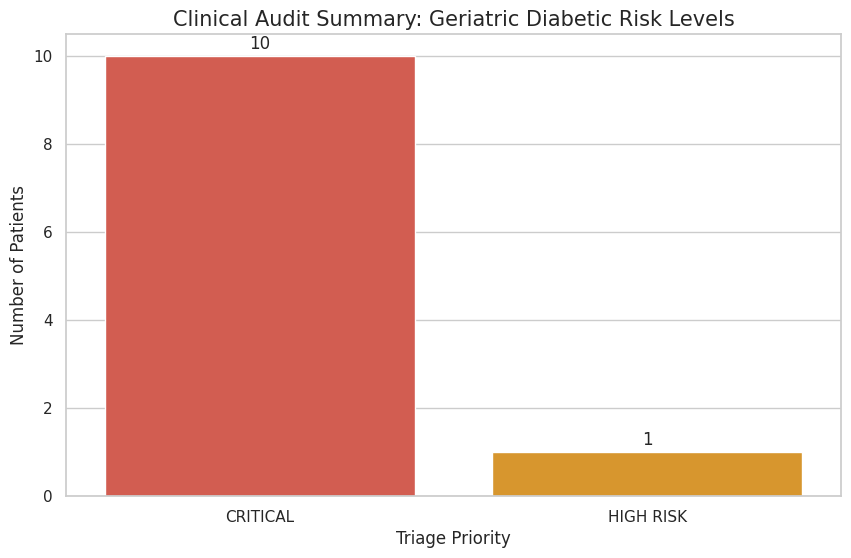

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Figure size 640x480 with 0 Axes>

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Create the count plot
ax = sns.countplot(data=df_pro_audit, x='triage_level', palette={'CRITICAL': '#e74c3c', 'HIGH RISK': '#f39c12'})

# Add labels and title
plt.title('Clinical Audit Summary: Geriatric Diabetic Risk Levels', fontsize=15)
plt.xlabel('Triage Priority', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)

# Add counts on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points')

plt.show()

# Save the figure to the Colab environment
plt.savefig('clinical_audit_chart.png', dpi=300, bbox_inches='tight')

# This part allows you to download it directly to your computer
from google.colab import files
files.download('clinical_audit_chart.png')